In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

C:\Users\imash\anaconda3\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("aseemdandgaval/23-pet-breeds-image-classification")

print("Path to dataset files:", path)

In [2]:
# Path to your Kaggle dataset
base_dir = "23-pet-breeds-image-classification"
train_dir = os.path.join(base_dir, "train")  # 23 breed subfolders

# Check directory structure
print(os.listdir(train_dir)[:5])  # first 5 breeds

['abyssinian', 'american shorthair', 'beagle', 'boxer', 'bulldog']


In [3]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    validation_split=0.2  # 80% train, 20% validation
)

train_generator = train_datagen.flow_from_directory(
    '23-pet-breeds-image-classification/train/',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    '23-pet-breeds-image-classification/train/',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

Found 3105 images belonging to 23 classes.
Found 776 images belonging to 23 classes.


In [4]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False  # Freeze base

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(train_generator.num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 23)             │        29,463 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,287,447 (8.73 MB)

 Trainable params: 29,463 (115.09 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
EPOCHS = 10

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS
)

Epoch 1/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 348s 3s/step - accuracy: 0.5639 - loss: 1.5043 - val_accuracy: 0.7668 - val_loss: 0.7897
Epoch 2/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 718s 7s/step - accuracy: 0.7894 - loss: 0.6834 - val_accuracy: 0.7938 - val_loss: 0.6741
Epoch 3/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 340s 3s/step - accuracy: 0.8361 - loss: 0.5459 - val_accuracy: 0.8286 - val_loss: 0.5805
Epoch 4/10
90/98 ━━━━━━━━━━━━━━━━━━━━ 21s 3s/step - accuracy: 0.8756 - loss: 0.4118

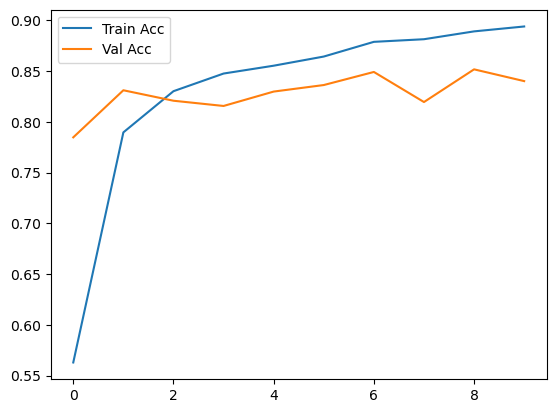

In [8]:
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.show()

In [ ]:
model.save("pet_breed_model.h5")

In [ ]:
import numpy as np
np.save("class_names.npy", list(train_generator.class_indices.keys()))